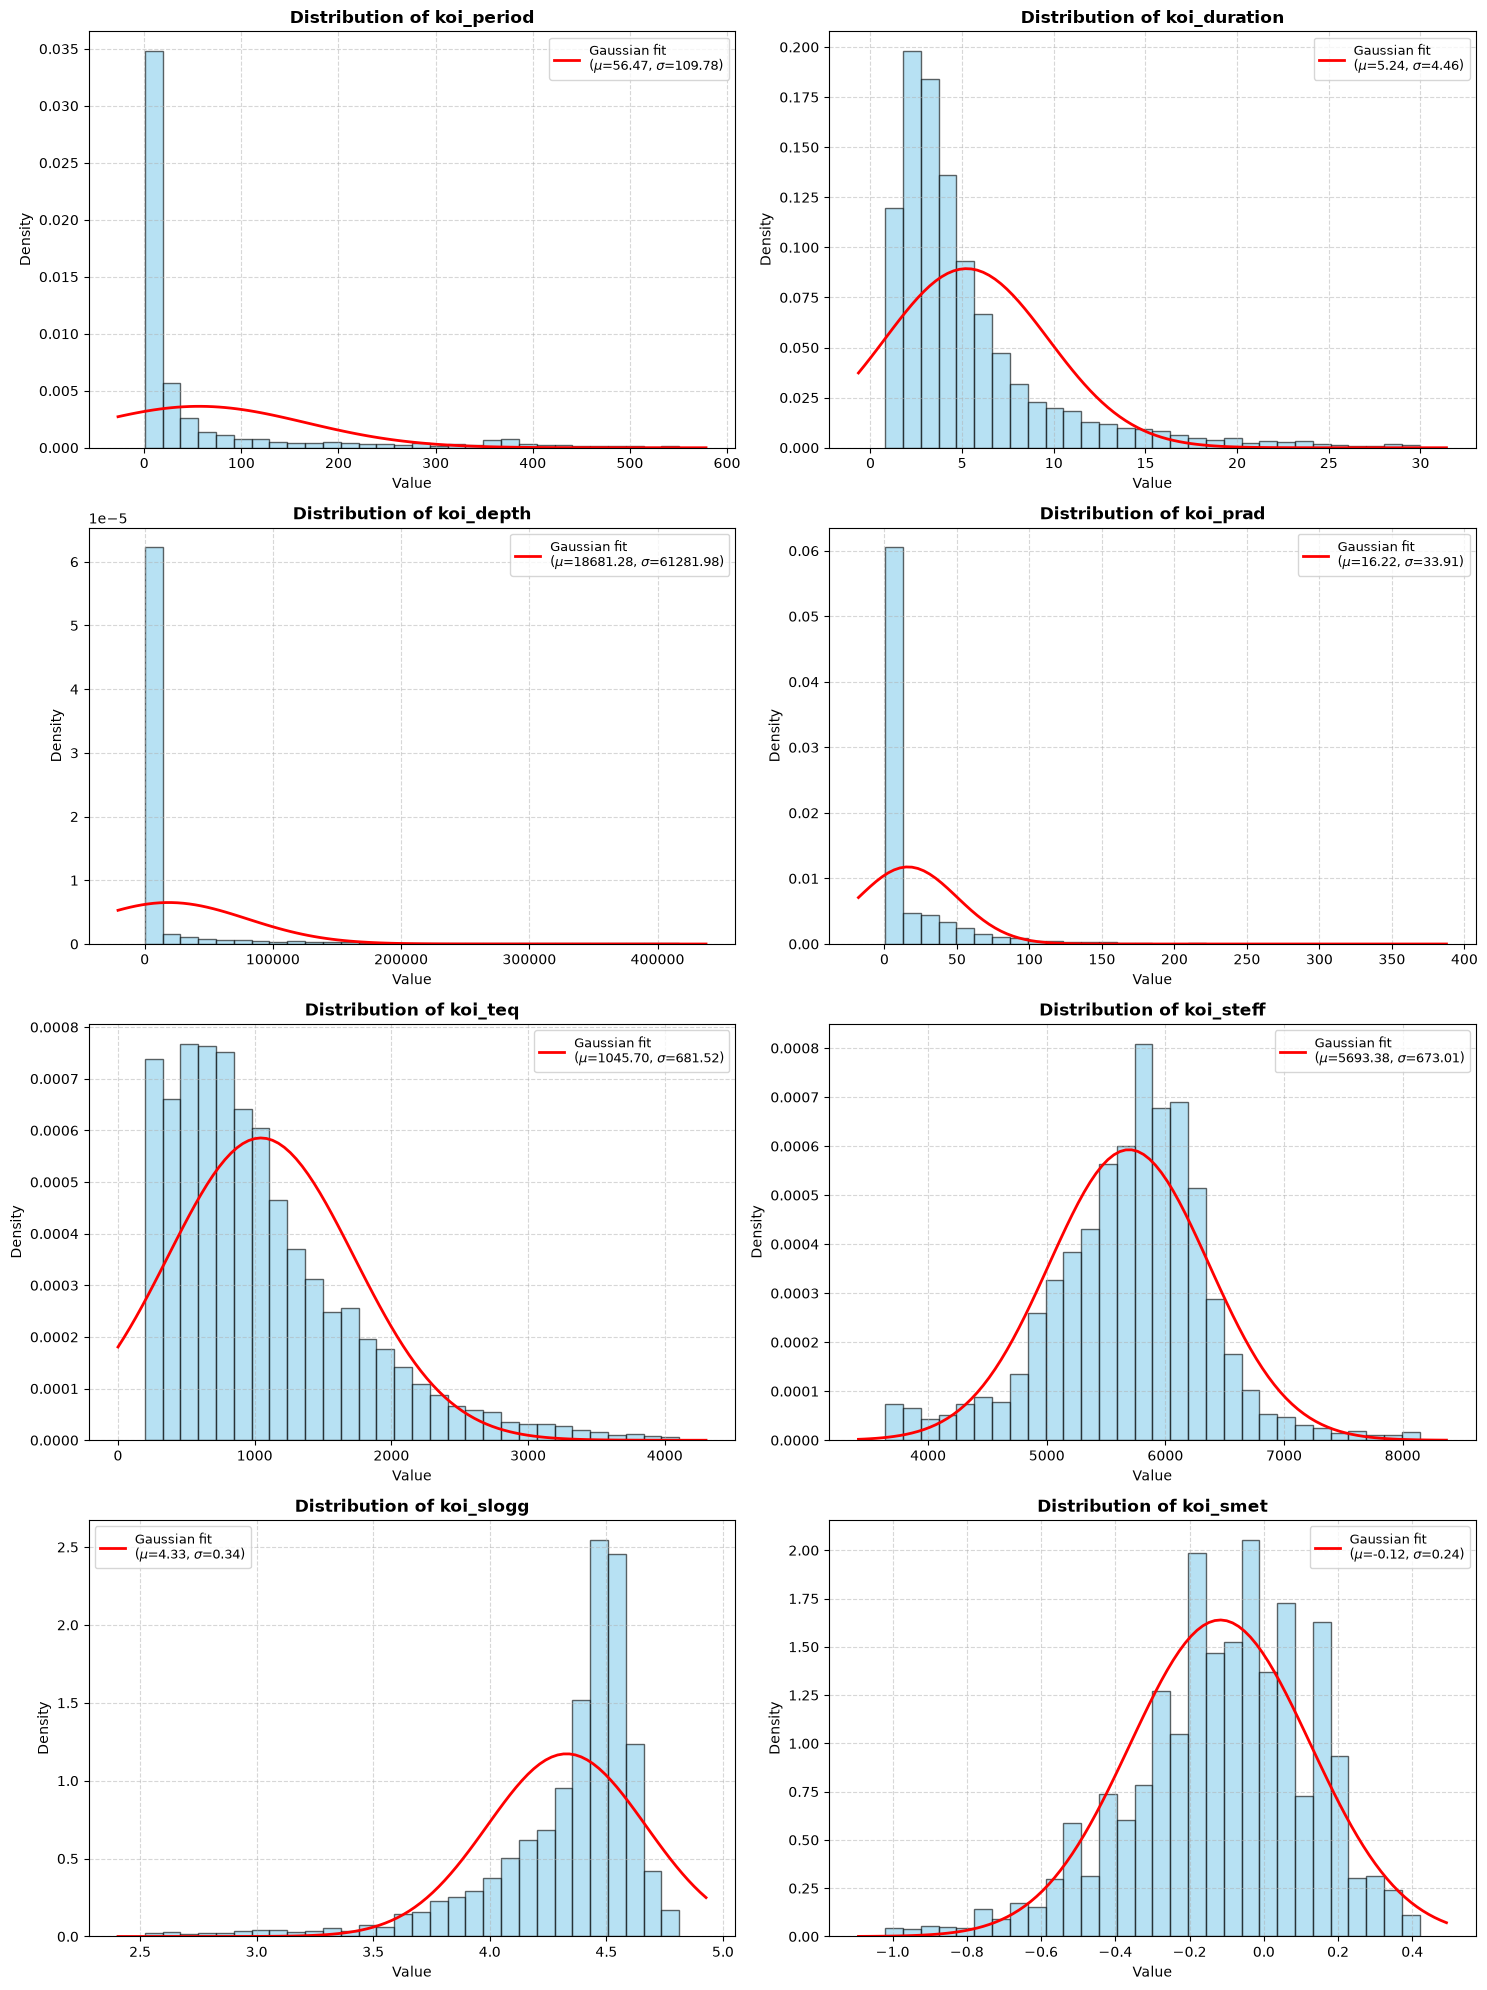

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

df = pd.read_csv("../cumulative_2026.06.24_09.53.31.csv", comment='#')

cols = [
    'koi_period', 'koi_duration', 'koi_depth', 'koi_prad',
    'koi_teq', 'koi_steff', 'koi_slogg', 'koi_smet'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = df[col].dropna()
    q_low = data.quantile(0.01)
    q_high = data.quantile(0.99)
    filtered_data = data[(data >= q_low) & (data <= q_high)]

    mean, standard_deviation = norm.fit(filtered_data)

    n, bins, patches = ax.hist(
        filtered_data,
        bins=30,
        density=True,
        alpha=0.6,
        color='skyblue',
        edgecolor='black'
    )

    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, standard_deviation)

    ax.plot(x, p, 'r-', linewidth=2, label=f'Gaussian fit\n($\mu$={mean:.2f}, $\sigma$={standard_deviation:.2f})')
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Loading metadata from: ../modified datasets/koi_cumulative_labeled.csv


C:\Users\Debomoy Patra\AppData\Local\Temp\ipykernel_34408\4265404357.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(dist_df['Class Name'], fontsize=11, fontweight='semibold')
findfont: Failed to find font weight semibold, now using 700.



DATASET CLASS DISTRIBUTION (5 CLASSES)
Class 0 - Transit                  :  4725 samples (49.40%)
Class 1 - Stellar Eclipse          :  2210 samples (23.11%)
Class 2 - Not Transit / Unlabeled  :  1299 samples (13.58%)
Class 3 - Centroid Offset          :  1206 samples (12.61%)
Class 4 - Ephemeris Match          :   124 samples (1.30%)
------------------------------------------------------------
Total dataset size: 9564 samples



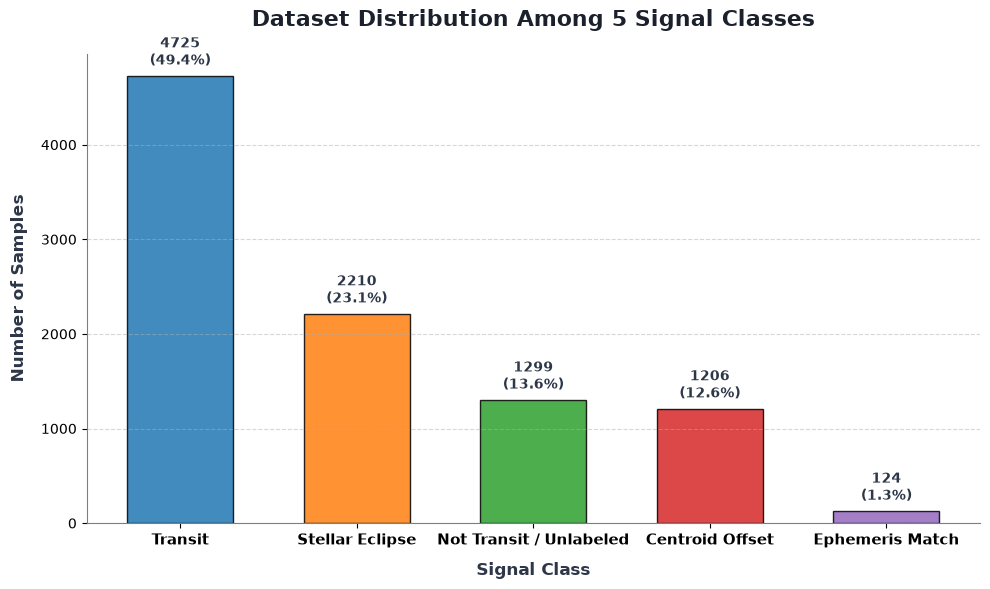

In [2]:
# # Dataset Class Distribution
# This cell plots and prints the distribution of the dataset among the 5 classes to understand the class imbalance.

import os
import pandas as pd
import matplotlib.pyplot as plt

# Dynamic path resolution to load metadata
csv_path = "../modified datasets/koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "../koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "modified datasets/koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "../dataset_index.csv"
if not os.path.exists(csv_path):
    csv_path = "dataset_index.csv"

print(f"Loading metadata from: {csv_path}")
df_meta = pd.read_csv(csv_path, comment='#')

# Label mapping to 5 classes:
# 0: transit, 1: stellar_eclipse, 2: not_transit, 3: centroid_offset, 4: Ephemeris match
label_mapping = {
    'transit': 0,
    'stellar_eclipse': 1,
    'not_transit': 2,
    'centroid_offset': 3,
    'Ephemeris match': 4,
    'unlabeled': 2
}
class_names = {
    0: 'Transit',
    1: 'Stellar Eclipse',
    2: 'Not Transit / Unlabeled',
    3: 'Centroid Offset',
    4: 'Ephemeris Match'
}

df_meta["label_idx"] = df_meta["signal_class"].apply(lambda x: label_mapping.get(x, 2))
df_meta["class_name"] = df_meta["label_idx"].map(class_names)

# Calculate distribution metrics
class_counts = df_meta["label_idx"].value_counts().sort_index()
total_samples = len(df_meta)
class_pcts = (class_counts / total_samples) * 100

# Create dataframe for plotting and display
dist_df = pd.DataFrame({
    'Class Index': class_counts.index,
    'Class Name': [class_names[i] for i in class_counts.index],
    'Count': class_counts.values,
    'Percentage (%)': class_pcts.values
})

# Display formatted table
print("\n" + "=" * 60)
print("DATASET CLASS DISTRIBUTION (5 CLASSES)")
print("=" * 60)
for idx, row in dist_df.iterrows():
    print(f"Class {row['Class Index']} - {row['Class Name']:<25}: {row['Count']:>5} samples ({row['Percentage (%)']:.2f}%)")
print("-" * 60)
print(f"Total dataset size: {total_samples} samples")
print("=" * 60 + "\n")

# Premium plotting
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']  # Curated colors
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

bars = ax.bar(dist_df['Class Name'], dist_df['Count'], color=colors, edgecolor='black', alpha=0.85, width=0.6)

# Highlight styling
ax.set_title('Dataset Distribution Among 5 Signal Classes', fontsize=16, fontweight='bold', pad=20, color='#1A202C')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold', labelpad=10, color='#2D3748')
ax.set_xlabel('Signal Class', fontsize=12, fontweight='bold', labelpad=10, color='#2D3748')
ax.set_xticklabels(dist_df['Class Name'], fontsize=11, fontweight='semibold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add text labels on top of the bars (Count + Percentage)
for bar, pct in zip(bars, dist_df['Percentage (%)']):
    height = bar.get_height()
    ax.annotate(f'{int(height)}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2D3748')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#718096')
ax.spines['bottom'].set_color('#718096')

plt.tight_layout()

# Save target plot
results_dir = "results" if os.path.exists("results") else "model_2/results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "class_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()


Using device: cuda
Loading metadata from: ../modified datasets/koi_cumulative_labeled.csv
Dataset directory: ../dataset
Checkpoint path: checkpoints/best_model.pth
Test Set Size: 1435 samples


C:\Users\Debomoy Patra\AppData\Local\Temp\ipykernel_34408\2481008892.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, m

Running model inference on test set...


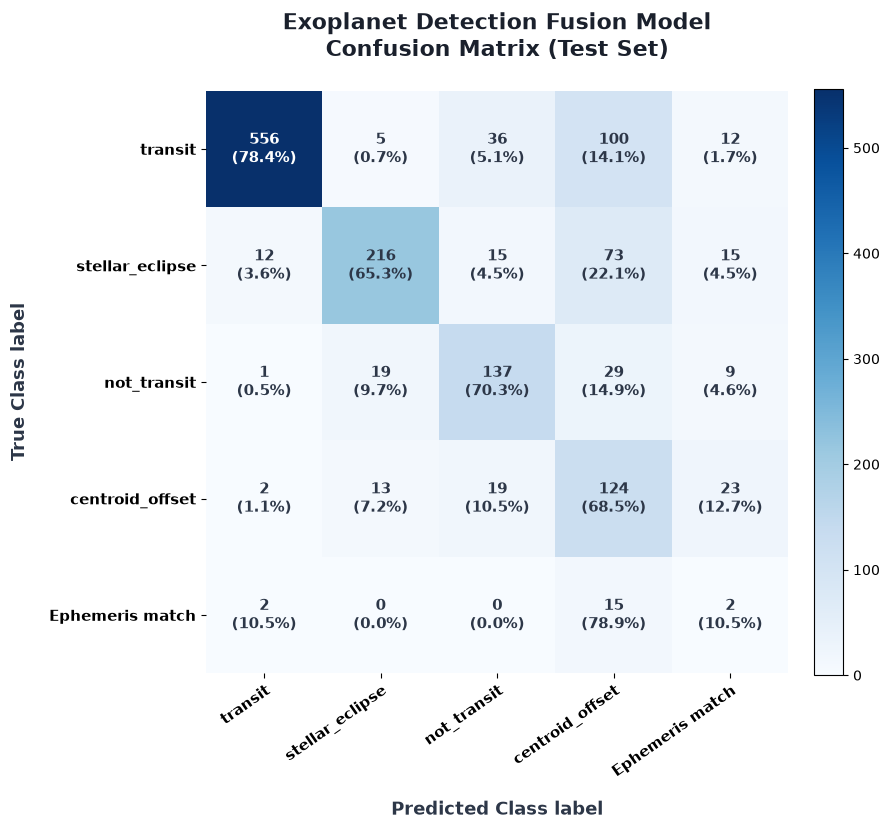


CLASSIFICATION METRICS REPORT
                 precision    recall  f1-score   support

        transit     0.9703    0.7842    0.8674       709
stellar_eclipse     0.8538    0.6526    0.7397       331
    not_transit     0.6618    0.7026    0.6816       195
centroid_offset     0.3636    0.6851    0.4751       181
Ephemeris match     0.0328    0.1053    0.0500        19

       accuracy                         0.7213      1435
      macro avg     0.5765    0.5859    0.5628      1435
   weighted avg     0.8126    0.7213    0.7524      1435



In [3]:
# # Exoplanet Model Evaluation: Confusion Matrix
# This cell loads the trained `ExoplanetLateFusionModel` and evaluates it on the holdout test set to generate a detailed Confusion Matrix.

import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Ensure paths are configured for importing custom modules
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('..'))

try:
    from model_2.data_load import ExoplanetDataset
    from model_2.concantecenattion import ExoplanetLateFusionModel
except ImportError:
    from data_load import ExoplanetDataset
    from concantecenattion import ExoplanetLateFusionModel

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dynamic path resolution for robust execution
checkpoint_path = "checkpoints/best_model.pth"
if not os.path.exists(checkpoint_path):
    checkpoint_path = "model_2/checkpoints/best_model.pth"

csv_path = "../modified datasets/koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "../koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "modified datasets/koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "../dataset_index.csv"
if not os.path.exists(csv_path):
    csv_path = "dataset_index.csv"

dataset_dir = "../dataset"
if not os.path.exists(dataset_dir):
    dataset_dir = "dataset"

print(f"Loading metadata from: {csv_path}")
print(f"Dataset directory: {dataset_dir}")
print(f"Checkpoint path: {checkpoint_path}")

# 3. Load metadata and reproduce the exact stratified test split (15%)
df_meta = pd.read_csv(csv_path, comment='#')

label_mapping = {
    'transit': 0,
    'stellar_eclipse': 1,
    'not_transit': 2,
    'centroid_offset': 3,
    'Ephemeris match': 4,
    'unlabeled': 2
}
df_meta["label_idx"] = df_meta["signal_class"].apply(lambda x: label_mapping.get(x, 2))

# Stratified split: Train (70%), Val (15%), Test (15%) matching train.py
train_val_df, test_df = train_test_split(
    df_meta,
    test_size=0.15,
    random_state=42,
    stratify=df_meta["label_idx"]
)
print(f"Test Set Size: {len(test_df)} samples")

# 4. Instantiate dataset and dataloader
test_dataset = ExoplanetDataset(test_df, dataset_dir, augment=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False)

# 5. Load model architecture and best checkpoint weights
num_classes = 5
model = ExoplanetLateFusionModel(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# 6. Evaluation loop to gather predictions
all_preds = []
all_targets = []

print("Running model inference on test set...")
with torch.no_grad():
    for x_global, x_local, x_stellar, y_class, y_reg, y_conf in test_loader:
        x_global = x_global.to(device)
        x_local = x_local.to(device)
        x_stellar = x_stellar.to(device)
        
        class_logits, _, _, _, _ = model(x_global, x_local, x_stellar)
        probs = model.get_probabilities(class_logits)
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_targets.extend(y_class.numpy())

# Convert to numpy arrays
all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

# 7. Compute confusion matrix
classes = ['transit', 'stellar_eclipse', 'not_transit', 'centroid_offset', 'Ephemeris match']
cm = confusion_matrix(all_targets, all_preds, labels=np.arange(num_classes))

# 8. Premium Plotting of Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 9), facecolor='white')
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Setup layout aesthetic parameters
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=11, fontweight='semibold')
ax.set_yticklabels(classes, fontsize=11, fontweight='semibold')

# Set labels and title
ax.set_title('Exoplanet Detection Fusion Model\nConfusion Matrix (Test Set)', fontsize=16, fontweight='bold', pad=25, color='#1A202C')
ax.set_ylabel('True Class label', fontsize=13, fontweight='bold', labelpad=15, color='#2D3748')
ax.set_xlabel('Predicted Class label', fontsize=13, fontweight='bold', labelpad=15, color='#2D3748')

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")

# Iterate over cells and add formatted text labels (Count + Percentage)
threshold = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        row_sum = cm[i].sum()
        percentage_str = ""
        if row_sum > 0:
            percentage = cm[i, j] / row_sum * 100
            percentage_str = f"\n({percentage:.1f}%)"
        
        cell_text = f"{cm[i, j]}{percentage_str}"
        text_color = "white" if cm[i, j] > threshold else "#2D3748"
        ax.text(j, i, cell_text,
                ha="center", va="center",
                color=text_color,
                fontsize=11, fontweight='bold')

# Remove outer box lines and clean up appearance
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Save target paths
results_dir = "results" if os.path.exists("results") else "model_2/results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

# 9. Output Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION METRICS REPORT")
print("=" * 60)
print(classification_report(all_targets, all_preds, target_names=classes, digits=4))
print("=" * 60)
